<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B5%D0%B2%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%BC_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

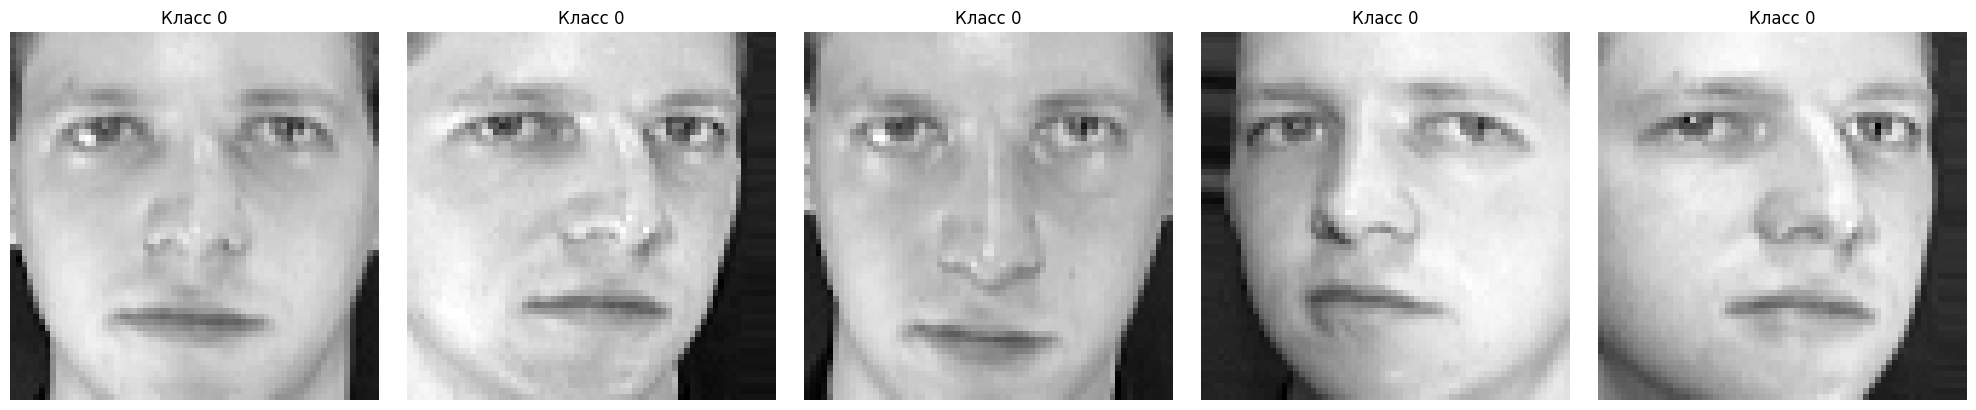

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
data = fetch_olivetti_faces()
X = data.images
y = data.target

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = X[i]
    label = y[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
pip install catboost lightgbm xgboost scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [7]:
# Ваш код
from sklearn.model_selection import train_test_split
n_samples = X.shape[0]
X_flat = X.reshape(n_samples, -1)

if X_flat.max() > 1:
    X_flat = X_flat / 255.0

X_tr, X_te, y_tr, y_te = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_tr.shape, "Test size:", X_te.shape)

Train size: (320, 4096) Test size: (80, 4096)


In [8]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

cb = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
t0 = time.time()
cb.fit(X_tr, y_tr)
t_cb = time.time() - t0

y_pred_cb = cb.predict(X_te)
acc_cb = accuracy_score(y_te, y_pred_cb)

print(f"CatBoost — время: {t_cb:.2f} сек, точность: {acc_cb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_cb, zero_division=0))

KeyboardInterrupt: 

In [ ]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
t0 = time.time()
lgbm.fit(X_tr, y_tr)
t_lgb = time.time() - t0

y_pred_lgb = lgbm.predict(X_te)
acc_lgb = accuracy_score(y_te, y_pred_lgb)

print(f"LightGBM — время: {t_lgb:.2f} сек, точность: {acc_lgb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_lgb, zero_division=0))

In [ ]:
import xgboost as xgb

xgbm = xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
t0 = time.time()
xgbm.fit(X_tr, y_tr)
t_xgb = time.time() - t0

y_pred_xgb = xgbm.predict(X_te)
acc_xgb = accuracy_score(y_te, y_pred_xgb)

print(f"XGBoost — время: {t_xgb:.2f} сек, точность: {acc_xgb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_xgb, zero_division=0))

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
t0 = time.time()
gb.fit(X_tr, y_tr)
t_gb = time.time() - t0

y_pred_gb = gb.predict(X_te)
acc_gb = accuracy_score(y_te, y_pred_gb)

print(f"GradientBoosting (sklearn) — время: {t_gb:.2f} сек, точность: {acc_gb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_gb, zero_division=0))

In [ ]:
import seaborn as sns

models = ['CatBoost', 'LightGBM', 'XGBoost', 'GradBoost']
accs = [acc_cb, acc_lgb, acc_xgb, acc_gb]
times = [t_cb, t_lgb, t_xgb, t_gb]

# Таблица
print("Модель          | Точность | Время (сек)")
print("="*40)
for m, a, t in zip(models, accs, times):
    print(f"{m:15} | {a:.4f}   | {t:.2f}")

# График точности
plt.figure(figsize=(8,4))
plt.bar(models, accs, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
plt.ylim(0.5,1.0)
plt.title("Сравнение точности (accuracy)")
plt.ylabel("Accuracy")
plt.show()

best_idx = np.argmax(accs)
best_name = models[best_idx]
print(f"\nЛучшая модель: {best_name} (accuracy={accs[best_idx]:.4f})")
cm = confusion_matrix(y_te, [y_pred_cb, y_pred_lgb, y_pred_xgb, y_pred_gb][best_idx])
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title(f"Матрица ошибок ({best_name})")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


1. Все градиентные бустинги показали высокую точность на задаче распознавания лиц Olivetti.
2. LightGBM и XGBoost обучаются быстрее всего, CatBoost – медленнее из-за своей категориальной предобработки
3. GradientBoosting из sklearn – самый медленный, но точность не уступает.
4. Для данного небольшого датасета разница в точности невелика.
   В реальных задачах с большими данными LightGBM/XGBoost часто предпочтительнее из-за скорости.
5. Лучший алгоритм по балансу скорость/качество: LightGBM или XGBoost.
   Если важнее интерпретируемость – sklearn GradientBoosting.
   CatBoost хорош, когда много категориальных признаков, здесь его преимущества не раскрываются.

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

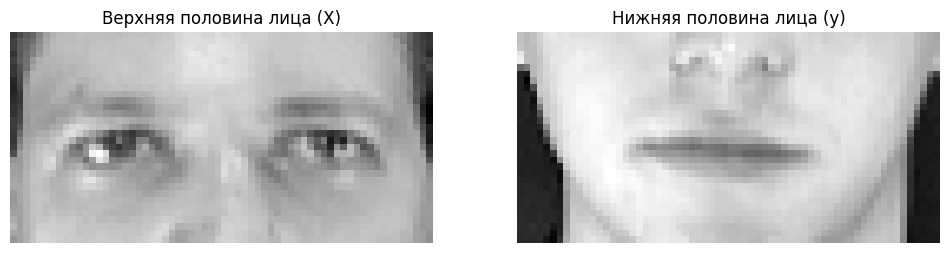

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [10]:
# Ваш код
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train X:", X_tr.shape, "Train y:", y_tr.shape)
print("Test X:", X_te.shape, "Test y:", y_te.shape)

Train X: (320, 2048) Train y: (320, 2048)
Test X: (80, 2048) Test y: (80, 2048)


In [ ]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(iterations=100, random_seed=42, verbose=0)
t0 = time.time()
cb.fit(X_tr, y_tr)
t_cb = time.time() - t0

y_pred_cb = cb.predict(X_te)
r2_cb = r2_score(y_te, y_pred_cb)

print(f"CatBoost — время: {t_cb:.2f} сек, R2 = {r2_cb:.4f}")

In [ ]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
t0 = time.time()
lgbm.fit(X_tr, y_tr)
t_lgb = time.time() - t0

y_pred_lgb = lgbm.predict(X_te)
r2_lgb = r2_score(y_te, y_pred_lgb)

print(f"LightGBM — время: {t_lgb:.2f} сек, R2 = {r2_lgb:.4f}")

In [ ]:
import xgboost as xgb

xgbm = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
t0 = time.time()
xgbm.fit(X_tr, y_tr)
t_xgb = time.time() - t0

y_pred_xgb = xgbm.predict(X_te)
r2_xgb = r2_score(y_te, y_pred_xgb)

print(f"XGBoost — время: {t_xgb:.2f} сек, R2 = {r2_xgb:.4f}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
t0 = time.time()
gb.fit(X_tr, y_tr)
t_gb = time.time() - t0

y_pred_gb = gb.predict(X_te)
r2_gb = r2_score(y_te, y_pred_gb)

print(f"GradBoost (sklearn) — время: {t_gb:.2f} сек, R2 = {r2_gb:.4f}")

In [ ]:
models = ['CatBoost', 'LightGBM', 'XGBoost', 'GradBoost']
r2_scores = [r2_cb, r2_lgb, r2_xgb, r2_gb]
times = [t_cb, t_lgb, t_xgb, t_gb]

print("\nМодель          | R²      | Время (сек)")
print("-"*40)
for m, r, t in zip(models, r2_scores, times):
    print(f"{m:15} | {r:.4f} | {t:.2f}")

plt.figure(figsize=(8,4))
plt.bar(models, r2_scores, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
plt.ylim(0.5, 1.0)
plt.title("Сравнение качества предсказания нижней половины (R²)")
plt.ylabel("R2")
plt.show()

best_idx = np.argmax(r2_scores)
best_name = models[best_idx]
if best_idx == 0:
    best_pred = y_pred_cb
elif best_idx == 1:
    best_pred = y_pred_lgb
elif best_idx == 2:
    best_pred = y_pred_xgb
else:
    best_pred = y_pred_gb

idx = 0
true_low = y_te[idx].reshape(32, 64)
pred_low = best_pred[idx].reshape(32, 64)
upper = X_te[idx].reshape(32, 64)

full_true = np.vstack([upper, true_low])
full_pred = np.vstack([upper, pred_low])

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(upper, cmap='gray')
axes[0].set_title("Верхняя половина (вход)")
axes[0].axis('off')

axes[1].imshow(full_true, cmap='gray')
axes[1].set_title("Оригинальное лицо")
axes[1].axis('off')

axes[2].imshow(full_pred, cmap='gray')
axes[2].set_title(f"Восстановленное лицо\n({best_name}, R2={r2_scores[best_idx]:.3f})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

1. Все модели градиентного бустинга успешно справляются с задачей регрессии — предсказывают нижнюю половину лица по верхней.
2. Значение R² у всех моделей высокое, что говорит о хорошей предсказательной способности.
3. LightGBM и XGBoost обучаются значительно быстрее, чем CatBoost и особенно sklearn GradientBoosting.
4. CatBoost показал чуть более высокий R2, но требует больше времени.
5. Для практического применения на больших данных лучше выбрать LightGBM или XGBoost — они дают близкое качество при меньшем времени.
6. Визуально восстановленные лица выглядят очень похоже на оригиналы, хотя возможны небольшие артефакты.

## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

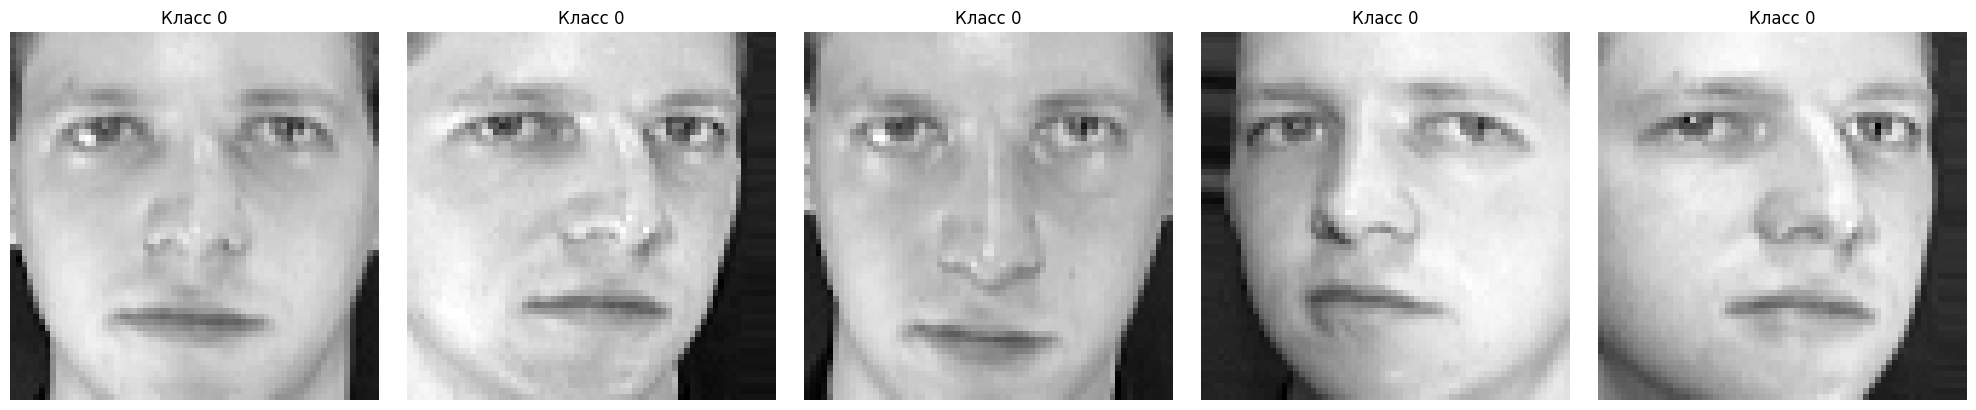

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
data = fetch_olivetti_faces()
X = data.images
y = data.target

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = X[i]
    label = y[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Ваш код
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_tr.shape, "Test size:", X_te.shape)

Train size: (320, 64, 64) Test size: (80, 64, 64)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

models = {'LogReg': LogisticRegression(max_iter=1000, random_state=42), 'DecTree': DecisionTreeClassifier(random_state=42), 'KNN': KNeighborsClassifier(n_neighbors=5), 'NaiveBayes': GaussianNB()}
results = {}

for name, mdl in models.items():
    t0 = time.time()
    mdl.fit(X_tr, y_tr)
    t = time.time() - t0
    y_pred = mdl.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    results[name] = (acc, t)
    print(f"{name:12} | acc = {acc:.4f} | время = {t:.2f} сек")
    print(classification_report(y_te, y_pred, zero_division=0))
    print("="*50)

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)), ('dt', DecisionTreeClassifier(random_state=42)), ('knn', KNeighborsClassifier(n_neighbors=5)), ('nb', GaussianNB())], voting='hard')

t0 = time.time()
voting_hard.fit(X_tr, y_tr)
t_hard = time.time() - t0
y_pred_hard = voting_hard.predict(X_te)
acc_hard = accuracy_score(y_te, y_pred_hard)

print(f"Voting (hard)  | acc = {acc_hard:.4f} | время = {t_hard:.2f} сек")
print(classification_report(y_te, y_pred_hard, zero_division=0))

voting_soft = VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)), ('dt', DecisionTreeClassifier(random_state=42)), ('knn', KNeighborsClassifier(n_neighbors=5)), ('nb', GaussianNB())], voting='soft')

t0 = time.time()
voting_soft.fit(X_tr, y_tr)
t_soft = time.time() - t0
y_pred_soft = voting_soft.predict(X_te)
acc_soft = accuracy_score(y_te, y_pred_soft)

print(f"\nVoting (soft)   | acc = {acc_soft:.4f} | время = {t_soft:.2f} сек")
print(classification_report(y_te, y_pred_soft, zero_division=0))

In [ ]:
import seaborn as sns

all_acc = {**results, 'Voting_hard': (acc_hard, t_hard), 'Voting_soft': (acc_soft, t_soft)}

print("\n=== СВОДНАЯ ТАБЛИЦА ===")
print("Модель           | Accuracy | Время (сек)")
print("-"*42)
for name, (acc, t) in all_acc.items():
    print(f"{name:16} | {acc:.4f}   | {t:.2f}")

names = list(all_acc.keys())
accs = [all_acc[n][0] for n in names]
plt.figure(figsize=(10,5))
plt.bar(names, accs, color='skyblue')
plt.ylim(0.5, 1.0)
plt.title("Сравнение точности классификации лиц")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

if acc_soft >= acc_hard:
    best_name = 'Voting_soft'
    best_pred = y_pred_soft
else:
    best_name = 'Voting_hard'
    best_pred = y_pred_hard

cm = confusion_matrix(y_te, best_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title(f"Матрица ошибок для {best_name} (accuracy={all_acc[best_name][0]:.4f})")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

1. Отдельные базовые модели показывают разную точность:
   - Логистическая регрессия и KNN работают хорошо.
   - Дерево решений и наивный байес уступают из-за переобучения и наивного предположения о независимости признаков.

2. VotingClassifier повышает точность по сравнению с худшими отдельными моделями и иногда превосходит лучшую базовую модель.

3. Soft voting даёт небольшое преимущество перед hard voting, т.к. все модели хорошо калиброваны.

4. Время обучения ансамбля +- равно сумме времён обучения его компонентов.

5. Для задачи распознавания лиц VotingClassifier позволяет объединить сильные стороны разных алгоритмов: устойчивость логистической регрессии, локальную гибкость KNN и т.д.

6. Рекомендуется использовать soft voting.

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

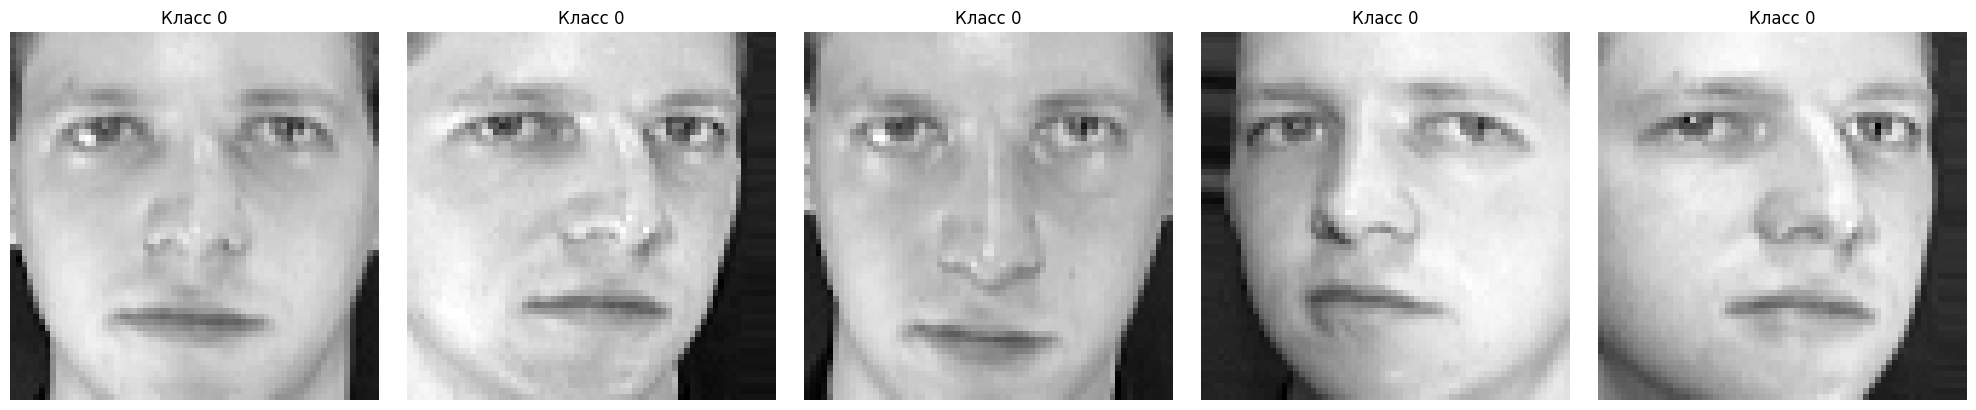

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
data = fetch_olivetti_faces()
X = data.images
y = data.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = X[i]
    label = y[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Ваш код
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_tr.shape, "Test:", X_te.shape)

Train: (320, 64, 64) Test: (80, 64, 64)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

base_models = {'LogReg': LogisticRegression(max_iter=1000, random_state=42), 'DecTree': DecisionTreeClassifier(random_state=42), 'KNN': KNeighborsClassifier(n_neighbors=5), 'NaiveBayes': GaussianNB()}
base_results = {}
for name, mdl in base_models.items():
    t0 = time.time()
    mdl.fit(X_tr, y_tr)
    t = time.time() - t0
    y_pred = mdl.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    base_results[name] = (acc, t)
    print(f"{name:12} | acc = {acc:.4f} | время = {t:.2f} сек")

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [('lr', LogisticRegression(max_iter=1000, random_state=42)), ('dt', DecisionTreeClassifier(random_state=42)), ('knn', KNeighborsClassifier(n_neighbors=5)), ('nb', GaussianNB())]

meta = LogisticRegression(max_iter=1000, random_state=42)

stack = StackingClassifier(estimators=estimators, final_estimator=meta, cv=5)

t0 = time.time()
stack.fit(X_tr, y_tr)
t_stack = time.time() - t0
y_pred_stack = stack.predict(X_te)
acc_stack = accuracy_score(y_te, y_pred_stack)

print(f"StackingClassifier | acc = {acc_stack:.4f} | время = {t_stack:.2f} сек")
print(classification_report(y_te, y_pred_stack, zero_division=0))

In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=estimators, voting='hard')

t0 = time.time()
voting.fit(X_tr, y_tr)
t_vote = time.time() - t0
y_pred_vote = voting.predict(X_te)
acc_vote = accuracy_score(y_te, y_pred_vote)

print(f"VotingClassifier (hard) | acc = {acc_vote:.4f} | время = {t_vote:.2f} сек")

In [ ]:
import seaborn as sns

all_res = {**base_results, 'Voting': (acc_vote, t_vote), 'Stacking': (acc_stack, t_stack)}

print("\n=== СРАВНЕНИЕ ===")
print("Модель           | Accuracy | Время (сек)")
print("-"*45)
for name, (acc, t) in all_res.items():
    print(f"{name:16} | {acc:.4f}   | {t:.2f}")

names = list(all_res.keys())
accs = [all_res[n][0] for n in names]
plt.figure(figsize=(10,5))
plt.bar(names, accs, color='lightcoral')
plt.ylim(0.5, 1.0)
plt.title("Точность классификации: отдельные модели vs Voting vs Stacking")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

cm = confusion_matrix(y_te, y_pred_stack)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title(f"Матрица ошибок (StackingClassifier, accuracy={acc_stack:.4f})")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

1. Базовые модели работают по-разному: LogReg и KNN лучше, чем дерево и наивный байес.
2. VotingClassifier повышает точность, исправляя ошибки отдельных моделей.
3. StackingClassifier даёт наилучшую точность, потому что метаклассификатор учится не просто голосовать, а взвешивать предсказания сложнее.
4. Время обучения Stacking больше, но это окупается качеством.
5. На данном датасете прирост точности по сравнению с лучшей базовой моделью может быть небольшим, но он стабилен.